# 2x2 charge-light event display — quickstart

Everything you need is in this folder. Run the setup cell once, then use any of the modes below.

**Displays**: blue curves = measured light waveforms, one box per SiPM channel on the two light walls of a TPC (labels are `adc:channel`). Center = charge hits (z–y, colored by drift x).

Works with regular charge+light FLOW files **and light-only files** (e.g. nearline `flowed_light` — see Mode 4).

*Optional prettier colors*: run `pip install --user cmasher cmcrameri` once in a terminal (the notebook works fine without).

In [1]:
# setup — run once
import cl_display as cl

# any 2x2 FLOW file works; this is a july10_2024 beam file
FLOW_FILE = ("/global/cfs/cdirs/dune/www/data/2x2/reflows/v10/flow/beam/"
             "july10_2024/nominal_hv/"
             "packet-0050018-2024_07_10_09_36_12_CDT.FLOW.hdf5")
h5, tbl = cl.open_flow(FLOW_FILE)

opened packet-0050018-2024_07_10_09_36_12_CDT.FLOW.hdf5: 113362 charge events, 8658 light events (1000-tick window), 8469 charge-light pairs


## Mode 1 — I know both ids
Fill in a **charge event id** and a **light event id** (they do not need to be associated): the light event's waveforms go on the two walls, the charge event's hits in the center.

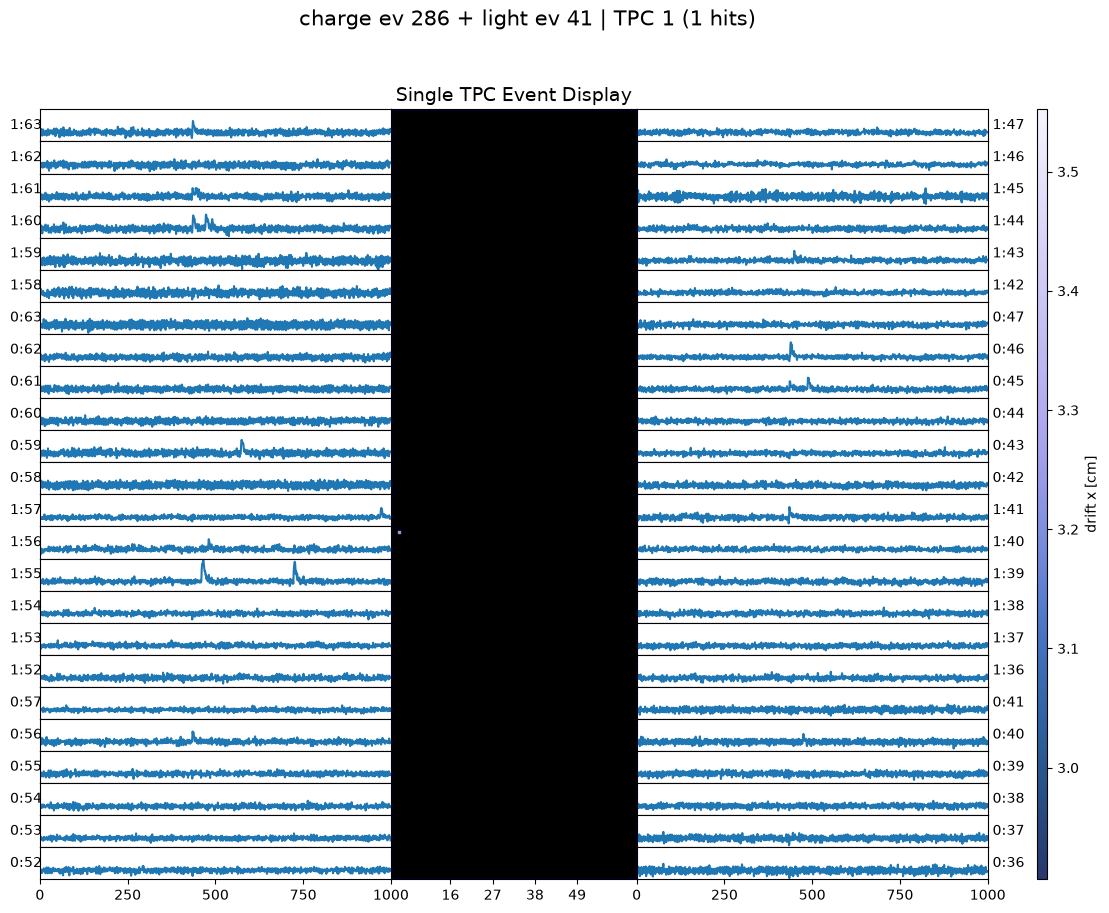

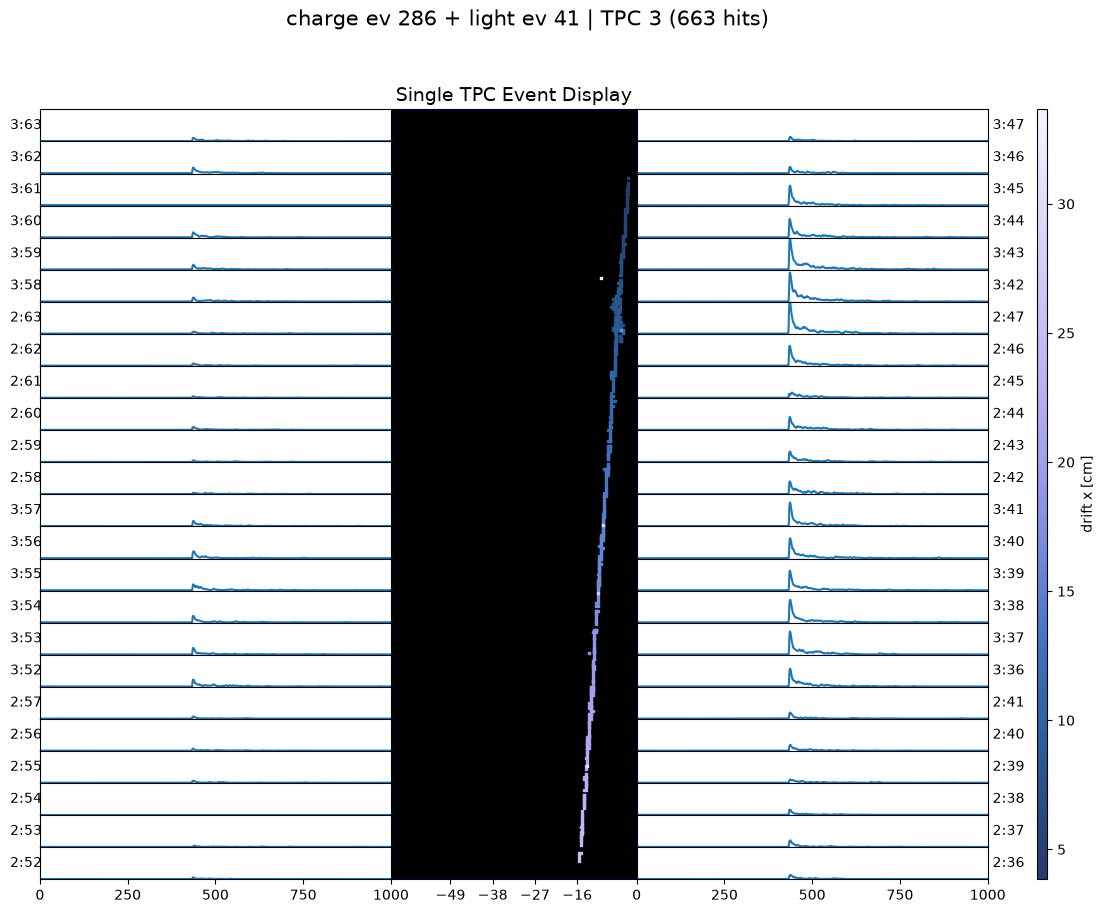

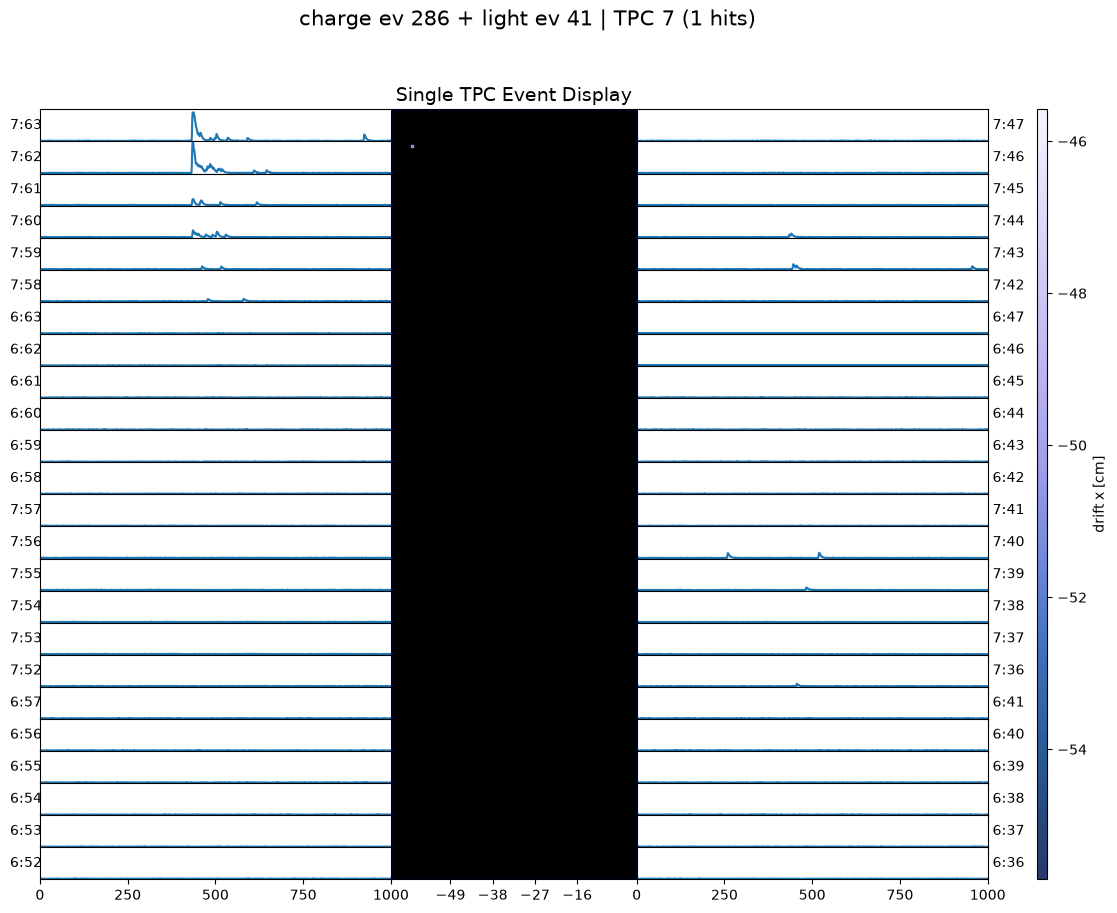

In [2]:
charge_ev = 286      # <-- fill in
light_ev  = 41       # <-- fill in

cl.show_pair(h5, tbl, charge_ev, light_ev)

## Mode 2 — I only know the charge event id
The associated light event is looked up automatically from the reference table. If the charge event has no light partner you get `no light found!`.

charge ev 286 -> light ev 41


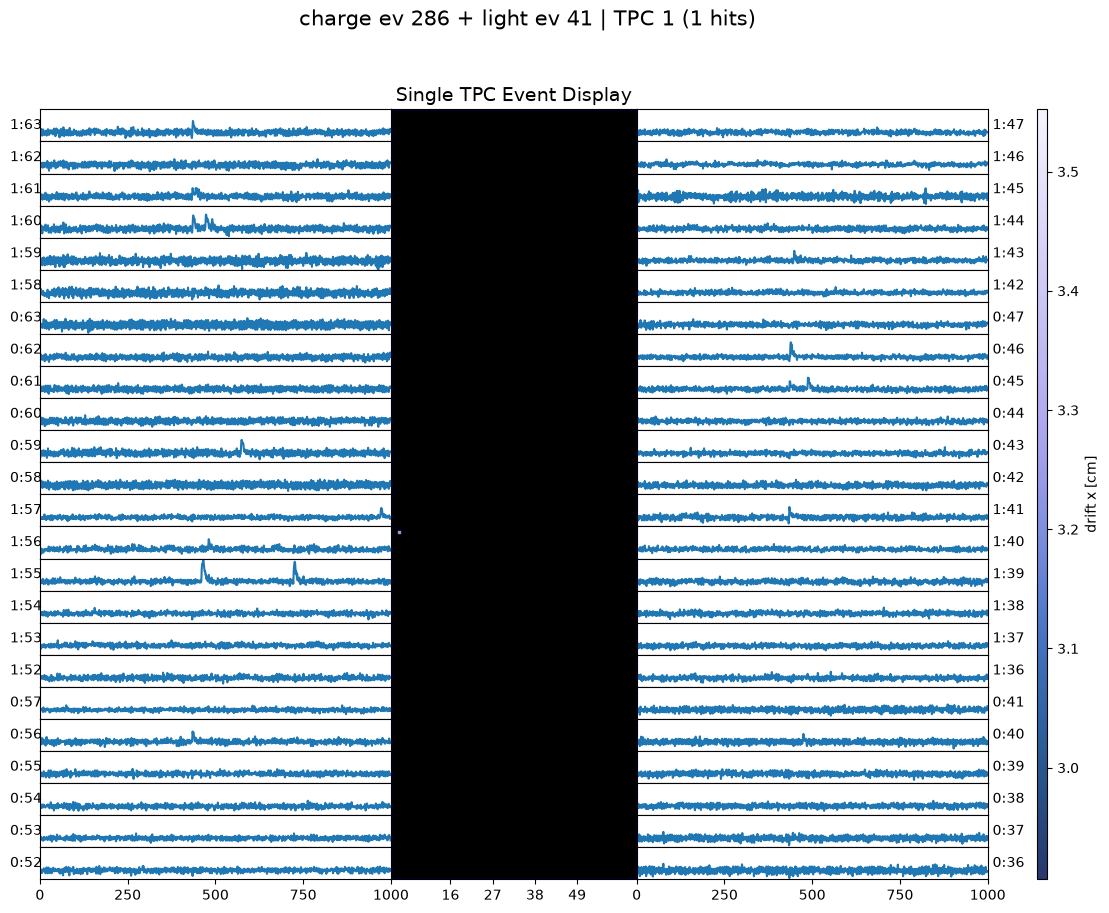

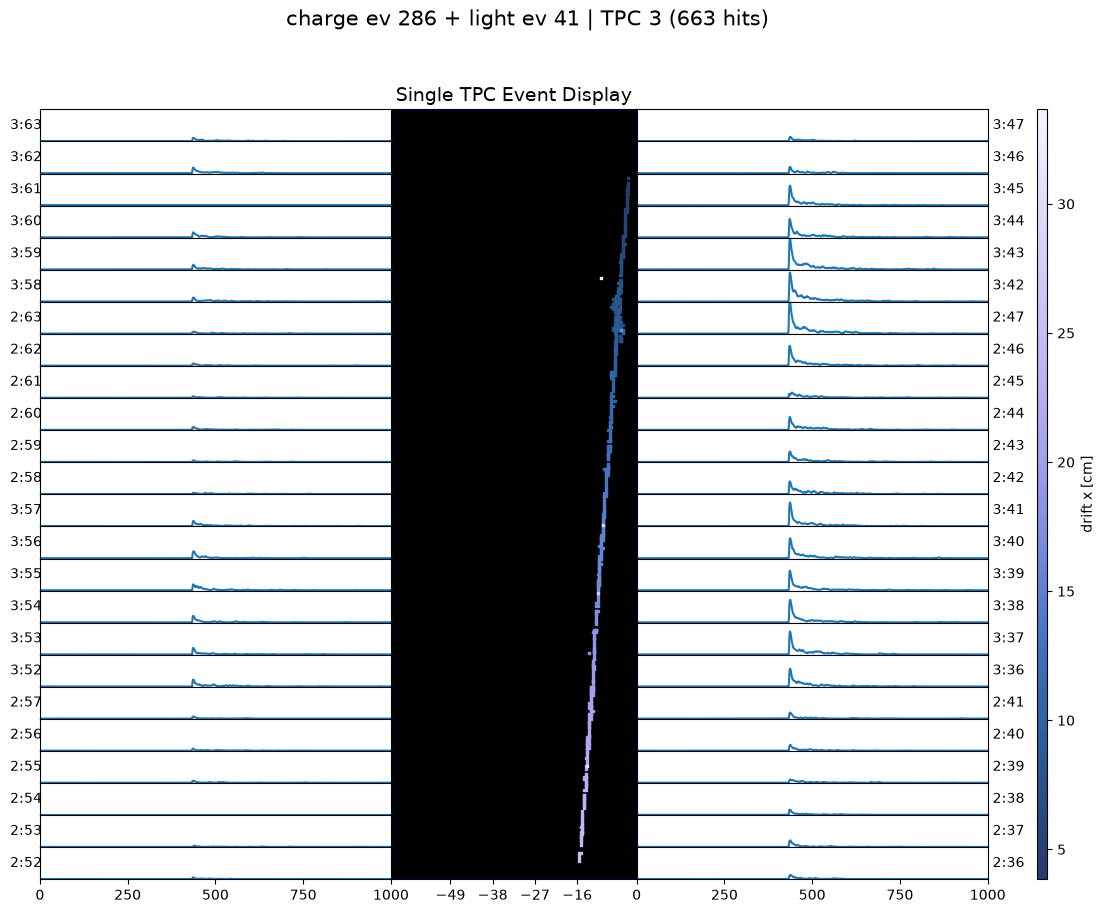

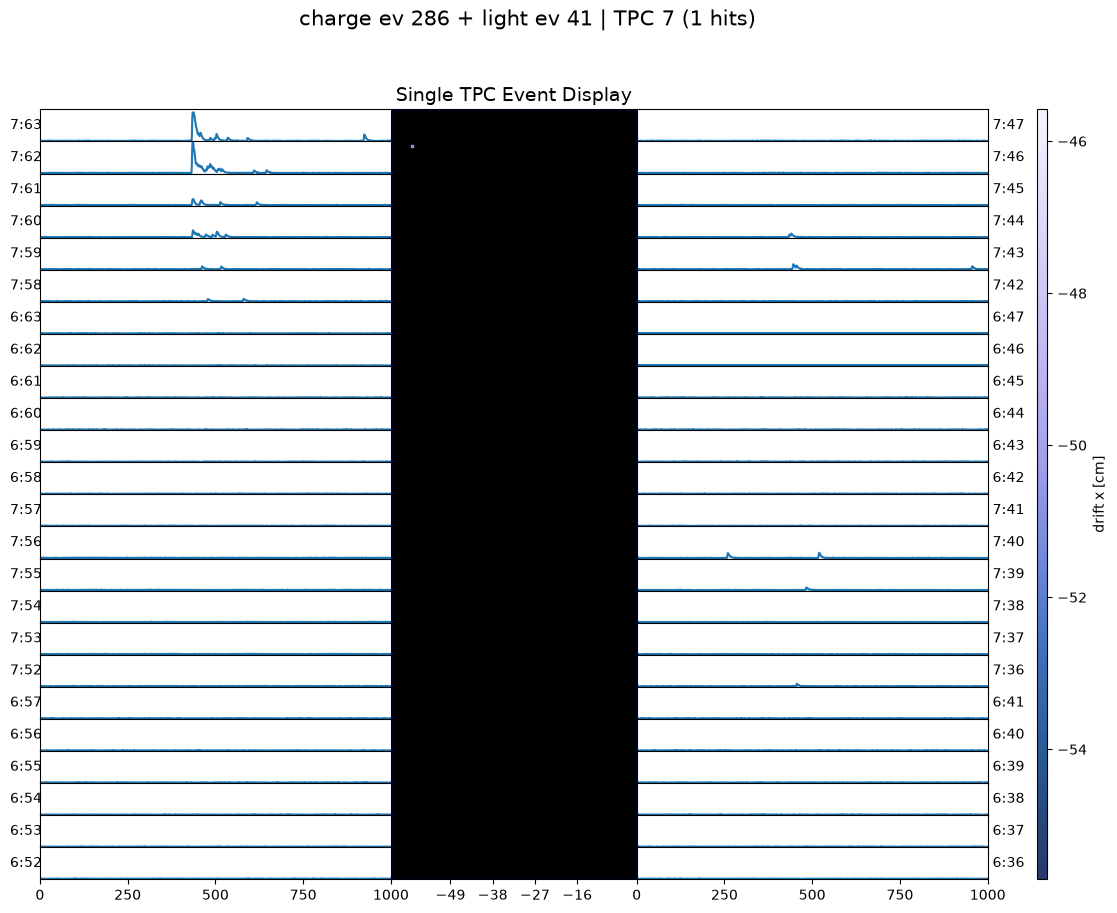

In [3]:
charge_ev = 286      # <-- fill in

cl.show_charge(h5, tbl, charge_ev)

## Mode 3 — I only know the light event id
Reverse lookup: find the charge event associated with this light event. If none exists you still get the light-only display.

light ev 41 -> charge ev 286


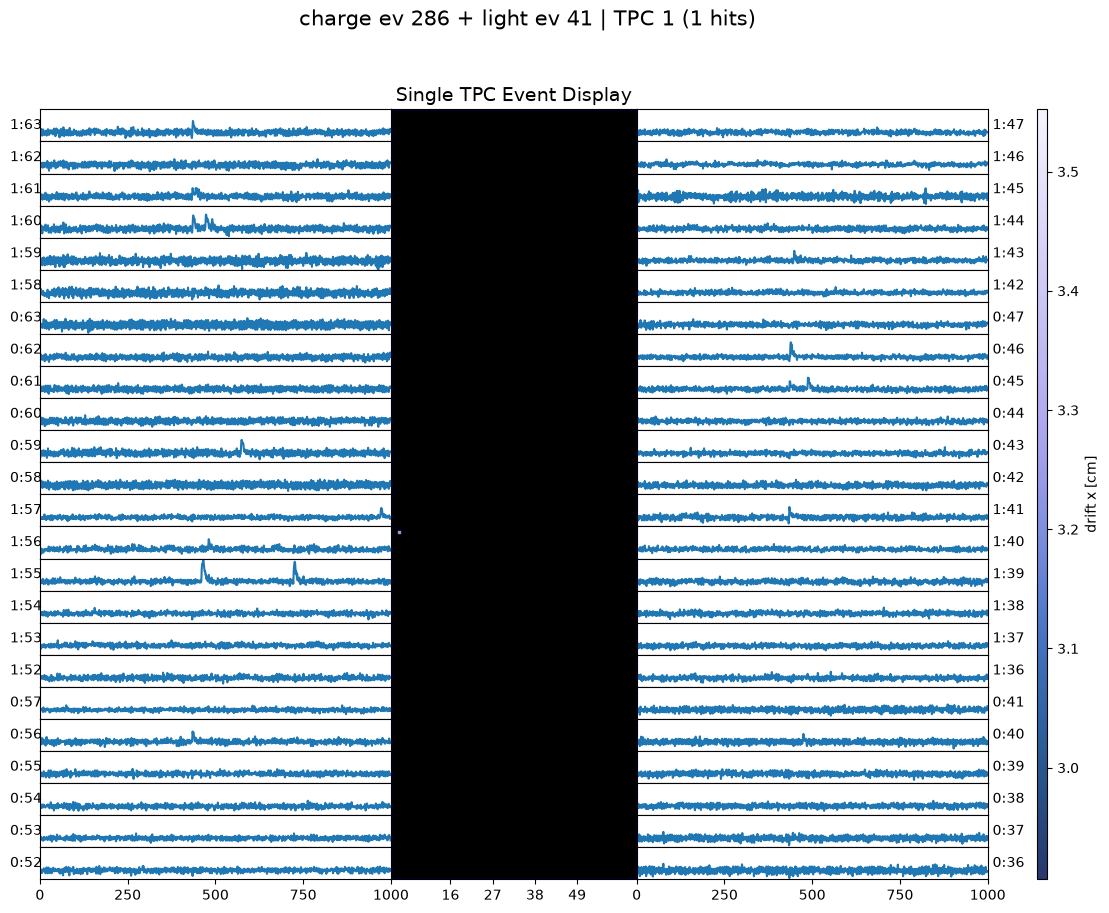

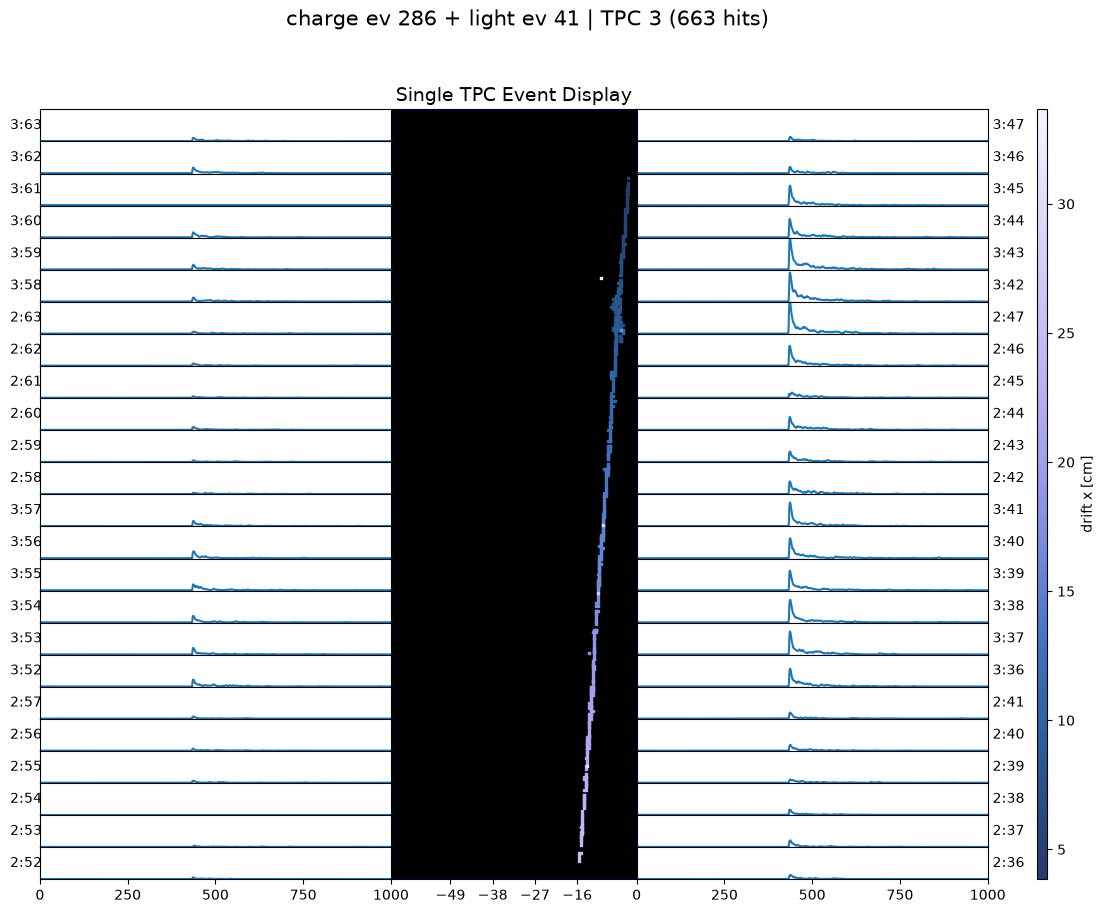

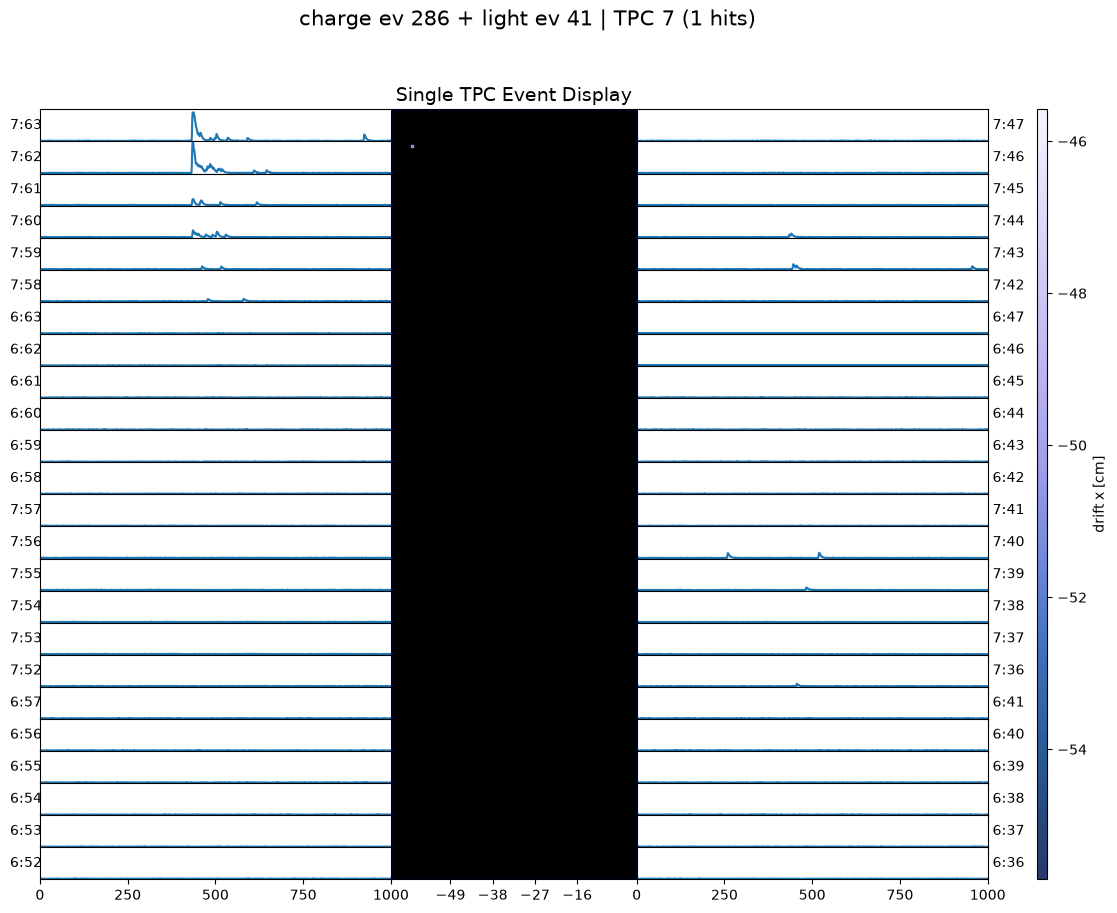

In [4]:
light_ev = 41        # <-- fill in

cl.show_light(h5, tbl, light_ev)

## Mode 4 — light-only files (nearline `flowed_light`)
Some files contain only light (no charge at all), e.g. cold-commissioning / purity runs. Open them the same way — the center panel stays empty and everything else works. Use `tpc="all"` to see all 8 TPCs, or `tpc=3` for one.

*(These files may have a different window length, e.g. 600 ticks — handled automatically. If the file has no geometry info, the bundled july10_2024 channel map is used; a note is printed.)*

note: file has no geometry_info — using the bundled july10_2024 channel map (verify if the run's cabling differs)
opened mpd_run_data_2026_09_07_17_18_06_CST_001282_p00000.FLOW.hdf5: LIGHT-ONLY file, 3265 light events (600-tick window)


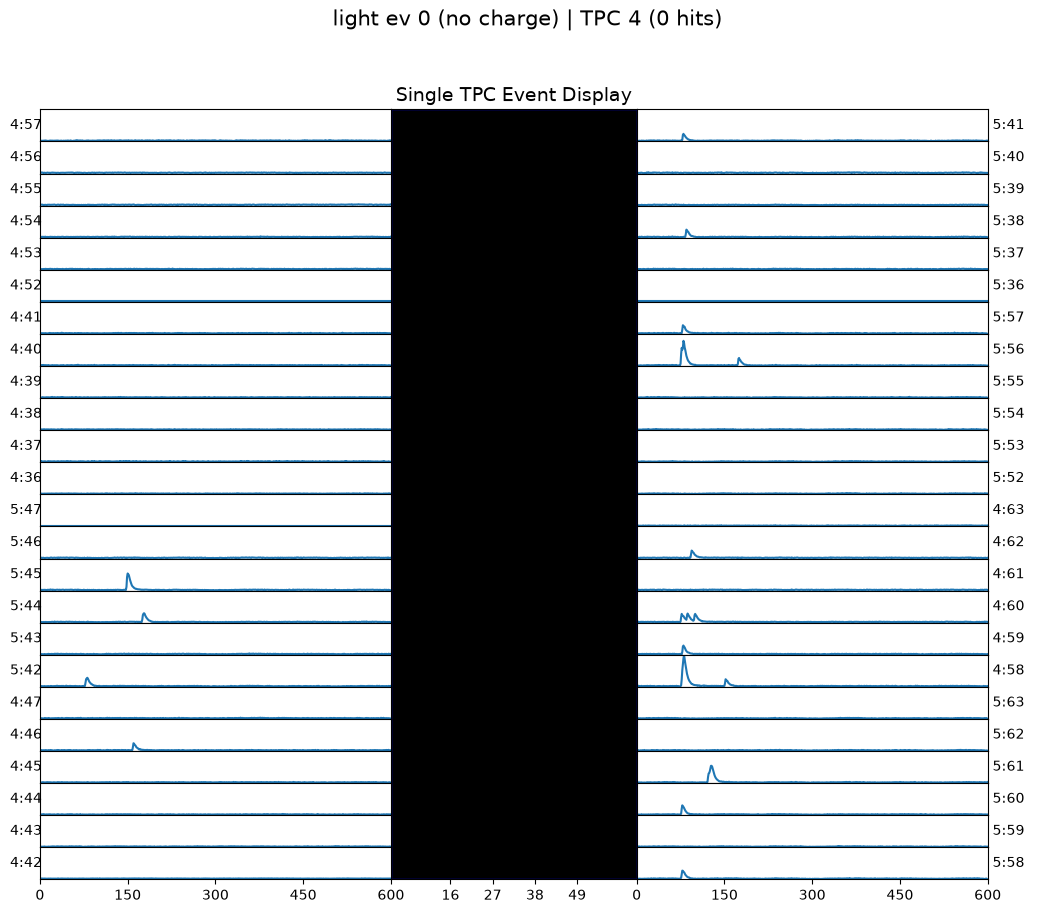

In [5]:
LIGHT_FILE = ("/global/cfs/cdirs/dune/www/data/2x2/nearline_run3/"
              "flowed_light/cold_commission/20260908_purity_co60/"
              "mpd_run_data_2026_09_07_17_18_06_CST_001282_p00000.FLOW.hdf5")
h5L, tblL = cl.open_flow(LIGHT_FILE)

light_ev = 0         # <-- fill in
cl.show_light_only(h5L, tblL, light_ev)          # brightest TPC
# cl.show_light_only(h5L, tblL, light_ev, tpc="all")   # all 8 TPCs

## Handy extras
```python
cl.find_light_for_charge(tbl, 286)     # -> light id or None
cl.find_charge_for_light(tbl, 41)      # -> charge id or None
x, y, z, E, tpc = cl.charge_hits(h5, tbl, 286)   # raw hit arrays
cl.show_pair(h5, tbl, 286, 41, tpc=3)  # force one specific TPC
```
To browse another file, re-run the setup cell with a different `FLOW_FILE` (any `.FLOW.hdf5` under `/global/cfs/cdirs/dune/www/data/2x2/`).